In [1]:
# ================================================================
# PART 1. VectorDB - 상품 의미 검색
# ================================================================

import chromadb
from chromadb.utils import embedding_functions

import networkx as nx        # 그래프 생성/분석 라이브러리 (PART 2 에서 사용)
import matplotlib.pyplot as plt  # 그래프 시각화
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [2]:
# ----------------------------------------------------------------
# 상품 데이터 준비
# ----------------------------------------------------------------
# 이커머스 상품 5개
# id   : 상품 고유 식별자 (GraphDB 에서 노드 id 로도 그대로 사용)
# name : 상품명
# desc : 상품 설명 → VectorDB 에 저장할 텍스트 (벡터로 변환됨)
# category : 상품 카테고리 → 메타데이터 필터링에 사용
products = [
    {
        "id": "p1",
        "name": "프로그래밍용 고성능 노트북",
        "desc": "최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다.",
        "category": "가전"
    },
    {
        "id": "p2",
        "name": "초경량 사무용 랩탑",
        "desc": "1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북.",
        "category": "가전"
    },
    {
        "id": "p3",
        "name": "전문가용 미러리스 카메라",
        "desc": "4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라.",
        "category": "가전"
    },
    {
        "id": "p4",
        "name": "편안한 러닝화",
        "desc": "쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화.",
        "category": "패션"
    },
    {
        "id": "p5",
        "name": "방수 트레킹화",
        "desc": "고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발.",
        "category": "패션"
    },
]

In [3]:
# ================================================================
# ChromaDB 클라이언트 & 임베딩 모델 설정
# ================================================================

client = chromadb.Client()
# 'paraphrase-multilingual-MiniLM-L12-v2'
#   - 50개 이상의 언어를 지원하는 다국어 모델
#   - 'jhgan/ko-sroberta-multitask' 보다 가볍고 빠름
#   - 한국어 포함 다국어 프로젝트에 적합
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='paraphrase-multilingual-MiniLM-L12-v2'
)

try:
    client.delete_collection('ecommerce')
except Exception:
    pass

product_collection = client.create_collection(
    name='ecommerce',
    embedding_function=st_ef,       # 다국어 임베딩 모델 지정
    metadata={'hnsw:space': 'cosine'}  # 코사인 유사도 사용
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:
# ================================================================
# 상품 데이터를 VectorDB 에 저장
# ================================================================

product_collection.add(
    ids=[f'product_{i:03d}' for i, p in enumerate(products)],

    # desc(상품 설명) 을 벡터로 변환해서 저장
    documents=[p['desc'] for p in products],

    # name, category 를 메타데이터로 저장
    metadatas=[
        {'name': p['name'], 'category': p['category']}
        for p in products
    ]
)

print(f'상품 {product_collection.count()}개 VectorDB 저장 완료')

상품 5개 VectorDB 저장 완료


In [5]:
# ================================================================
# 의미 기반 검색 테스트
# ================================================================
query = '산에 갈 때 신기 좋은 튼튼한 신발'

results = product_collection.query(
    query_texts=[query],
    n_results=2  
)

print(f'\n검색어: "{query}"')
print('-' * 50)

for doc, meta, dist in zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
):
    similarity = 1 - dist   
    print(f'상품명  : {meta["name"]}')
    print(f'유사도  : {similarity:.4f}')
    print(f'상품설명: {doc}')
    print()


검색어: "산에 갈 때 신기 좋은 튼튼한 신발"
--------------------------------------------------
상품명  : 방수 트레킹화
유사도  : 0.7860
상품설명: 고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발.

상품명  : 편안한 러닝화
유사도  : 0.4106
상품설명: 쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화.



In [6]:
# ================================================================
# PART 2. GraphDB - 구매/리뷰 신뢰도 분석 (NetworkX)
# ================================================================

# ----------------------------------------------------------------
# 그래프 생성
# ----------------------------------------------------------------

# nx.DiGraph() : 방향이 있는 그래프 생성
# DiGraph = Directed Graph (방향 그래프)
# 방향이 있다 = A→B 와 B→A 는 다른 관계
# 예) User_A → p5 (User_A 가 p5 를 구매)
#     p5 → User_A (X, 이런 방향은 없음)
# G = nx.DiGraph() : 방향성이 같으면 덮어쓰기 해버림
# 그래서 edge 수가 13 이 아닌 11이 나옴
import networkx as nx
G = nx.MultiDiGraph()
# ----------------------------------------------------------------
# 상품 노드 추가
# ----------------------------------------------------------------
for p in products:
    G.add_node(
        p['id'],        # 노드 id : 'p1', 'p2' ...
        type='Product', # 노드 타입 (나중에 색상 구분에 사용)
        name=p['name']  # 노드 이름 (시각화 라벨에 사용)
    )

# ----------------------------------------------------------------
# 유저 노드 추가
# ----------------------------------------------------------------
# 정상 유저 3명 + 스패머 2명
users = ['User_A', 'User_B', 'User_C', 'Spammer_1', 'Spammer_2']

for u in users:
    G.add_node(
        u,              # 노드 id
        type='User',    # 노드 타입
        name=u          # 노드 이름
    )


In [7]:
# ----------------------------------------------------------------
# 관계(엣지) 추가
# ----------------------------------------------------------------
# 정상 유저들의 패턴
# - 여러 다양한 상품을 구매
# - 서로 다른 유저들과 FOLLOWS 관계
# => 그래프에서 다양하게 연결 -> PageRank 점수 높아짐
edges = [
    ("User_A", "p5", "PURCHASED"),    # User_A 가 트레킹화 구매
    ("User_A", "p4", "PURCHASED"),    # User_A 가 러닝화 구매
    ("User_B", "p5", "PURCHASED"),    # User_B 가 트레킹화 구매
    ("User_B", "p1", "PURCHASED"),    # User_B 가 노트북 구매
    ("User_C", "p1", "PURCHASED"),    # User_C 가 노트북 구매
    ("User_C", "p3", "PURCHASED"),    # User_C 가 카메라 구매
    ("User_A", "User_B", "FOLLOWS"),  # User_A 가 User_B 팔로우
    ("User_B", "User_C", "FOLLOWS"),  # User_B 가 User_C 팔로우
]

# 스패머들의 패턴
# - p2(사무용 랩탑)에만 집중적으로 가짜 구매/리뷰
# - 자기들끼리만 FOLLOWS (외부와 단절된 고립 구조)
# => 그래프에서 고립되어 있음 -> PageRank 점수 낮아짐
spam_edges = [
    ("Spammer_1", "p2", "PURCHASED"),        # 스패머1 이 p2 가짜 구매
    ("Spammer_2", "p2", "PURCHASED"),        # 스패머2 이 p2 가짜 구매
    ("Spammer_1", "p2", "REVIEWED_5_STAR"),  # 스패머1 이 p2 에 5점 가짜 리뷰
    ("Spammer_2", "p2", "REVIEWED_5_STAR"),  # 스패머2 이 p2 에 5점 가짜 리뷰
    ("Spammer_1", "Spammer_2", "FOLLOWS"),   # 자기들끼리만 팔로우
]

# 모든 엣지를 그래프에 추가
# edges + spam_edges : 두 리스트를 합침
for src, dst, rel in edges + spam_edges:
    G.add_edge(
        src, dst,   # 출발 노드 -> 도착 노드
        type=rel    # 관계 타입 속성 저장
    )

print(f'그래프 생성 완료')
print(f'노드 수 : {G.number_of_nodes()}')  # 10 (상품5 + 유저5)
print(f'엣지 수 : {G.number_of_edges()}')  # 13

그래프 생성 완료
노드 수 : 10
엣지 수 : 13


In [8]:
# ================================================================
# PageRank 로 신뢰도 계산
# ================================================================

# ----------------------------------------------------------------
# 1단계 : 원본 그래프 PageRank (스패머 포함)
# ----------------------------------------------------------------
# nx.pagerank() : NetworkX 내장 PageRank 알고리즘
# alpha=0.85    : 감쇠 계수 (damping factor)
#   - 85% 확률로 실제 엣지를 따라 이동
#   - 15% 확률로 완전 랜덤하게 아무 노드로 이동
#   - 고립된 노드(스패머)는 랜덤 이동으로만 점수를 받아서 낮아짐
raw_pr_scores = nx.pagerank(G, alpha=0.85)

# ----------------------------------------------------------------
# 2단계 : 스패머 제거 후 신뢰도 보정 PageRank
# ----------------------------------------------------------------
# 스패머 노드 식별
# G.nodes(data=True) : 노드 id와 속성 딕셔너리를 함께 반환
# str(n).startswith('Spammer') : 노드 이름이 'Spammer'로 시작하면 스패머
suspicious_users = {
    n for n, data in G.nodes(data=True)
    if data['type'] == 'User' and str(n).startswith('Spammer')
}
print(f'\n탐지된 스패머: {suspicious_users}')

# 스패머를 제외한 노드 목록
trusted_nodes = [n for n in G.nodes() if n not in suspicious_users]

# G.subpraph() : 지정한 노드들만으로 이루어진 부분 그래프 추출
# .copy() : 원본 그래프 G를 변경하지 않도록 복사본 생성
trusted_G = G.subgraph(trusted_nodes).copy()

# 스패머가 제거된 그래프에서 PageRank 재계산
pr_scores = nx.pagerank(trusted_G, alpha=0.85)


탐지된 스패머: {'Spammer_2', 'Spammer_1'}


In [9]:
# ----------------------------------------------------------------
# 결과 출력 비교
# ----------------------------------------------------------------

print("원본 그래프 PageRank (스팸 영향 포함)")
print('-' * 50)
for node, score in sorted(raw_pr_scores.items(), key=lambda x: -x[1]):
    # lambda x: -x[1] : 점수 (두 번째 값) 기준 내림차순 정렬
    node_type = G.nodes[node]['type']
    name = G.nodes[node]['name']
    bar = '*' * int(score * 80) # 점수를 막대 길이로 시각화
    print(f'[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}')

print("\n신뢰도 보정 PageRank (Spammer 제거 후)")
print('-' * 50)
for node, score in sorted(pr_scores.items(), key=lambda x: -x[1]):
    node_type = trusted_G.nodes[node]['type']
    name = trusted_G.nodes[node]['name']
    bar = '*' * int(score * 80)
    print(f'[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}')

원본 그래프 PageRank (스팸 영향 포함)
--------------------------------------------------
[Product] 초경량 사무용 랩탑   | 점수: 0.177 **************
[Product] 프로그래밍용 고성능 노 | 점수: 0.129 **********
[Product] 방수 트레킹화      | 점수: 0.109 ********
[Product] 전문가용 미러리스 카메 | 점수: 0.105 ********
[User] User_C       | 점수: 0.091 *******
[Product] 편안한 러닝화      | 점수: 0.085 ******
[User] User_B       | 점수: 0.085 ******
[User] Spammer_2    | 점수: 0.085 ******
[User] User_A       | 점수: 0.066 *****
[User] Spammer_1    | 점수: 0.066 *****

신뢰도 보정 PageRank (Spammer 제거 후)
--------------------------------------------------
[Product] 프로그래밍용 고성능 노 | 점수: 0.175 **************
[Product] 방수 트레킹화      | 점수: 0.148 ***********
[Product] 전문가용 미러리스 카메 | 점수: 0.142 ***********
[User] User_C       | 점수: 0.123 *********
[Product] 편안한 러닝화      | 점수: 0.116 *********
[User] User_B       | 점수: 0.116 *********
[Product] 초경량 사무용 랩탑   | 점수: 0.090 *******
[User] User_A       | 점수: 0.090 *******


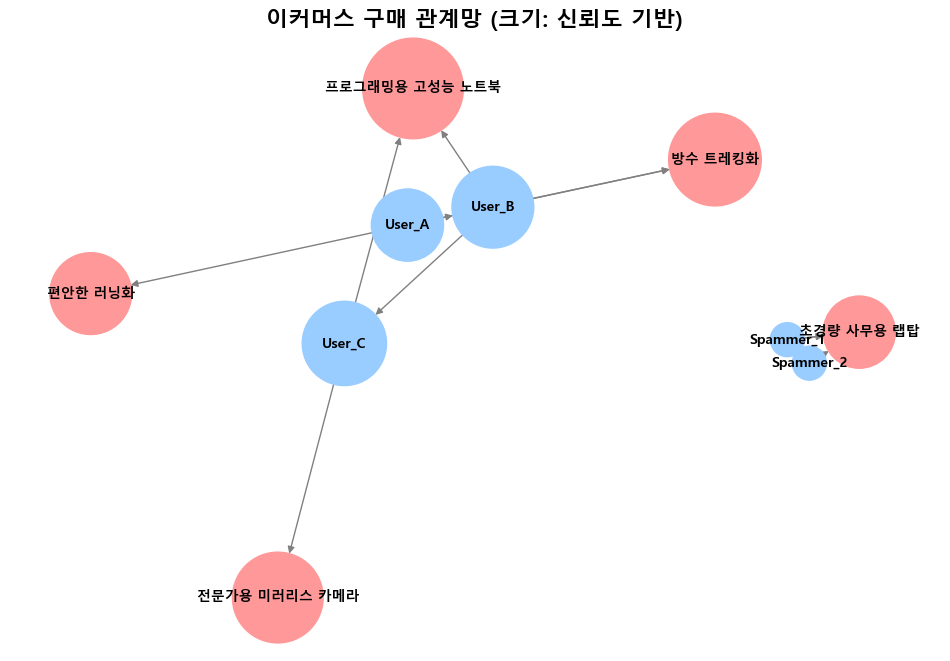

In [10]:
# ================================================================
# 그래프 시각화
# ================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# spring_layout : 연결이 많은 노드는 중앙으로, 고립 노드는 외곽으로 배치
# seed=42 : 매번 같은 위치로 고정 (재현성 확보)
pos = nx.spring_layout(G, seed=42)

# 노드 타입별 색상
color_map = {'Product': '#FF9999', 'User': '#99CCFF'}
colors = [color_map[G.nodes[n]['type']] for n in G.nodes()]

# 노드 크기 = PageRank 신뢰도 점수에 비례
# 스패머는 pr_scores 에 없으므로 기본값 0.02 사용 → 작게 표시
sizes = [pr_scores.get(n, 0.02) * 30000 for n in G.nodes()]

# 그래프 그리기
nx.draw(
    G, pos,
    with_labels=True,
    labels={n: G.nodes[n]['name'] for n in G.nodes()},  # 노드 라벨
    node_color=colors,     # 노드 색상
    node_size=sizes,       # 노드 크기 (신뢰도 비례)
    font_size=10,
    font_weight='bold',
    font_family='Malgun Gothic',
    edge_color='gray',
    arrows=True,           # 방향 화살표 표시
    ax=ax
)

plt.title('이커머스 구매 관계망 (크기: 신뢰도 기반)', fontsize=16, fontweight='bold')
plt.show()

In [11]:
# ================================================================
# PART 3. GraphRAG - 의미검색 + 신뢰도 통합 추천
# ================================================================

# ----------------------------------------------------------------
# Step 1. VectorDB 로 의미 검색 (후보 추출)
# ----------------------------------------------------------------
query = '산에 갈 때 신기 좋은 튼튼한 신발'

results = product_collection.query(
    query_texts=[query],
    n_results=5
)

print(f'검색어: "{query}"')
print('\n[ Step 1 ] VectorDB 의미 검색 결과 (신뢰도 고려 전)')
print('-' * 60)

for doc, meta, dist in zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
):
    similarity = 1 - dist
    print(f'유사도: {similarity:.4f} | 상품명: {meta["name"]}')

검색어: "산에 갈 때 신기 좋은 튼튼한 신발"

[ Step 1 ] VectorDB 의미 검색 결과 (신뢰도 고려 전)
------------------------------------------------------------
유사도: 0.7860 | 상품명: 방수 트레킹화
유사도: 0.4106 | 상품명: 편안한 러닝화
유사도: 0.1638 | 상품명: 초경량 사무용 랩탑
유사도: 0.0758 | 상품명: 전문가용 미러리스 카메라
유사도: -0.0030 | 상품명: 프로그래밍용 고성능 노트북


In [12]:
# ----------------------------------------------------------------
# Step 2. VectorDB 결과에 PageRank 신뢰도 합산
# ----------------------------------------------------------------
# VectorDB 의 id 와 GraphDB 의 노드 id 가 같아서 바로 연결 가능
print('\n[ Step 2 ] GraphRAG - 의미검색 + 신뢰도 통합')
print('-' * 60)

combined_scores = []

for i, (doc, meta, dist) in enumerate(zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
)):
    similarity = 1 - dist   # VectorDB 유사도 점수

    # products 리스트에서 해당 상품의 graph id (p1, p2,...) 가져오기
    # i번째 검색결과 -> products[i]의 id와 매핑
    product_id = products[i]['id']

    # PageRank 신뢰도 점수 가져오기
    # pr_scores에 없으면 0.0 (스패머 제거된 그래프 기준)
    trust_score = pr_scores.get(product_id, 0.0)

    # 최종 점수 = 유사요 60% + 신뢰도 40% 가중 합산
    # 비율은 조절 가능 (도메인에 따라 다르게 설정)
    final_score = (similarity * 0.6) + (trust_score * 0.4)

    combined_scores.append({
        'name': meta['name'],
        'product_id': product_id,
        'similarity': similarity,
        'trust': trust_score,
        'final': final_score
    })

# 최종 점수 기준으로 내림차순 정렬
combined_scores.sort(key=lambda x: -x['final'])

# 결과 출력
for rank, item in enumerate(combined_scores, start=1):
    print(
        f'{rank}위 | {item["name"][:15]:<15} | '
        f'유사도: {item["similarity"]:.3f} | '
        f'신뢰도: {item["trust"]:.3f} | '
        f'최종점수: {item["final"]:.3f}'
    )


[ Step 2 ] GraphRAG - 의미검색 + 신뢰도 통합
------------------------------------------------------------
1위 | 방수 트레킹화         | 유사도: 0.786 | 신뢰도: 0.175 | 최종점수: 0.542
2위 | 편안한 러닝화         | 유사도: 0.411 | 신뢰도: 0.090 | 최종점수: 0.282
3위 | 초경량 사무용 랩탑      | 유사도: 0.164 | 신뢰도: 0.142 | 최종점수: 0.155
4위 | 전문가용 미러리스 카메라   | 유사도: 0.076 | 신뢰도: 0.116 | 최종점수: 0.092
5위 | 프로그래밍용 고성능 노트북  | 유사도: -0.003 | 신뢰도: 0.148 | 최종점수: 0.058


In [13]:
# ----------------------------------------------------------------
# Step 3. 최종 추천 결과 출력
# ----------------------------------------------------------------

print('\n[ Step 3 ] 최종 추천 상품')
print('=' * 60)

top = combined_scores[0]   # 1위 상품
print(f'검색어  : "{query}"')
print(f'추천상품 : {top["name"]}')
print(f'최종점수 : {top["final"]:.3f}')
print(f'  → 의미유사도 {top["similarity"]:.3f} × 0.6')
print(f'     + 신뢰도  {top["trust"]:.3f} × 0.4')
print()
print('[ GraphRAG 가 Naive RAG 와 다른 점 ]')
print('  Naive RAG  : 유사도만 보고 추천 → 스팸 상품이 상위에 올 수 있음')
print('  GraphRAG   : 유사도 + 신뢰도 합산 → 진짜 좋은 상품이 상위에 옴')


[ Step 3 ] 최종 추천 상품
검색어  : "산에 갈 때 신기 좋은 튼튼한 신발"
추천상품 : 방수 트레킹화
최종점수 : 0.542
  → 의미유사도 0.786 × 0.6
     + 신뢰도  0.175 × 0.4

[ GraphRAG 가 Naive RAG 와 다른 점 ]
  Naive RAG  : 유사도만 보고 추천 → 스팸 상품이 상위에 올 수 있음
  GraphRAG   : 유사도 + 신뢰도 합산 → 진짜 좋은 상품이 상위에 옴


┌─────────────────────────────────────────────────────┐
│                   02.ipynb 전체 구조                   │
└─────────────────────────────────────────────────────┘

PART 1. VectorDB
│
│  상품 설명을 벡터로 변환해서 저장
│  "산에서 신을 신발" 같은 자연어로 의미 검색
│  → 텍스트가 비슷한 상품 후보 추출
│  → 문제: 스팸 상품도 걸러낼 수 없음
│
▼
PART 2. GraphDB (NetworkX)
│
│  유저 - 상품 - 리뷰 관계를 그래프로 모델링
│  PageRank 로 신뢰도 계산
│    스패머 포함  → p2 사무용랩탑 1위 (가짜 구매/리뷰)
│    스패머 제거  → p2 점수 급락, 진짜 상품들이 상위
│  → 문제: 검색 쿼리와 연결이 안 됨
│
▼
PART 3. GraphRAG
│
│  VectorDB 로 쿼리 관련 후보만 추림
│  그 후보들에 한해서만 PageRank 신뢰도 반영
│  최종점수 = 유사도 × 0.6 + 신뢰도 × 0.4
│  → 의미도 맞고 + 신뢰도도 높은 상품 추천